# Scatter plots

Two ways to draw points, and one unit difference between them that quietly breaks APS compliance.

All data here is synthetic and all axis labels are deliberately generic — this notebook is about how a
figure is built and styled, not about any particular measurement.

In [1]:
%matplotlib inline

# Jupyter crops every inline preview with bbox_inches="tight". That defeats the exact column widths
# this package exists to guarantee, and because the themes sit the axes close to the canvas edge, the
# crop slices through the top and right spines. Turn it off so previews match the files jf.save() writes.
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}

# jf.save() reports what it wrote through the "journalfig" logger instead of printing. Raise that one
# logger -- a blanket logging.basicConfig(level="INFO") also switches on fontTools, which logs a dozen
# subsetting lines per PDF.
import logging

logging.basicConfig(format="%(message)s")
logging.getLogger("journalfig").setLevel(logging.INFO)

import numpy as np
import matplotlib.pyplot as plt

import journalfig as jf

# The themes render previews at 600 dpi, which makes every embedded image in a notebook large. This
# only touches the on-screen preview; jf.save() exports at savefig.dpi regardless.
PREVIEW_DPI = 150


def preview(journal, **kwargs):
    """Apply a theme, then drop the on-screen DPI so this notebook stays light."""
    jf.use(journal, **kwargs)
    plt.rcParams["figure.dpi"] = PREVIEW_DPI


rng = np.random.default_rng(0)
print("journalfig", jf.__version__, "| themes:", jf.JOURNALS)

journalfig 0.4.0 | themes: ('nature', 'aps', 'elsevier')


## `plot` with markers, or `scatter`?

`ax.plot(..., linestyle="none")` draws markers through the property cycle and is the right choice for
a handful of series. `ax.scatter` is better when size or colour encodes a third variable.

Text(0, 0.5, 'y (a.u.)')

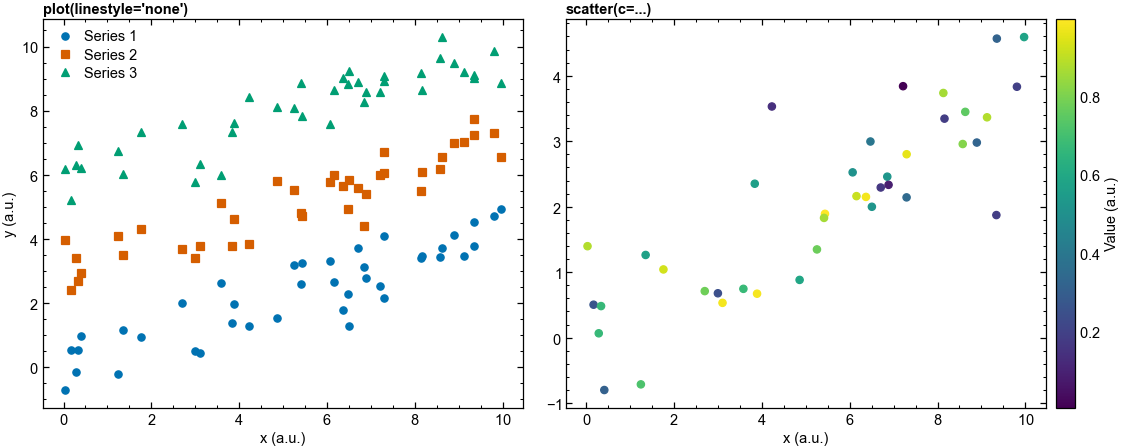

In [2]:
preview("elsevier")
x = rng.uniform(0, 10, 40)

fig, axs = jf.subplots("elsevier", 1, 2, width="double", ratio=0.4)
for i, marker in enumerate(jf.MARKER_CYCLE[:3]):
    axs[0].plot(x, 0.4 * x + rng.normal(0, 0.6, x.size) + i * 3, linestyle="none",
                marker=marker, label=f"Series {i + 1}")
axs[0].set_title("plot(linestyle='none')")
axs[0].legend()

third = rng.uniform(0, 1, x.size)
points = axs[1].scatter(x, 0.4 * x + rng.normal(0, 0.6, x.size), c=third, cmap="viridis")
axs[1].set_title("scatter(c=...)")
fig.colorbar(points, ax=axs[1], label="Value (a.u.)", fraction=0.05, pad=0.02)

for ax in axs:
    ax.set_xlabel("x (a.u.)")
axs[0].set_ylabel("y (a.u.)")

## The units trap

`lines.markersize` is a **diameter in points**. `scatter`'s `s` is an **area in points²**. The themes
feed `scatter` a default of `lines.markersize ** 2`, so an unstyled `scatter` already matches the rest
of the theme — but a hand-picked `s` does not mean what it looks like.

In [3]:
jf.use("aps")
fig, ax = plt.subplots()
print("theme lines.markersize :", plt.rcParams["lines.markersize"], "pt (diameter)")
print("scatter default s      :", ax.scatter([0], [0]).get_sizes(), "pt² (area)")
plt.close(fig)

mm_per_pt = 25.4 / 72
print()
print("APS requires data points >= 1 mm across:")
print(f"  1 mm            = {1 / mm_per_pt:.3f} pt of diameter")
print(f"  minimum s       = {(1 / mm_per_pt) ** 2:.1f} pt²")
print("  so s=4 looks harmless and is undersized")

theme lines.markersize : 4.0 pt (diameter)
scatter default s      : [16.] pt² (area)

APS requires data points >= 1 mm across:
  1 mm            = 2.835 pt of diameter
  minimum s       = 8.0 pt²
  so s=4 looks harmless and is undersized


`jf.check()` inspects scatter collections as well as line markers, so it catches both forms.

In [4]:
jf.use("aps")
fig, ax = jf.subplots("aps", width="single")
ax.scatter(x, 0.4 * x, s=4)
ax.plot(x, 0.4 * x + 3, linestyle="none", marker="o", markersize=1.5)
ax.set_xlabel("x (a.u.)")
ax.set_ylabel("y (a.u.)")

for violation in jf.check(fig, warn=False):
    print(violation)
plt.close(fig)

[marker] marker diameter is 0.53 mm, below the 1.0 mm minimum
[marker] scatter marker is 0.71 mm across (s=4 pt²), below the 1.0 mm minimum


Sized correctly, the same figure passes:

violations: []


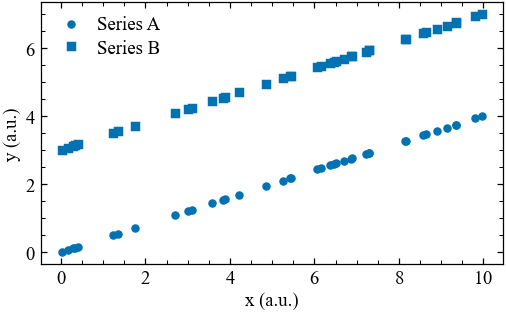

In [5]:
preview("aps")
fig, ax = jf.subplots("aps", width="single")
ax.scatter(x, 0.4 * x, s=12, label="Series A")
ax.plot(x, 0.4 * x + 3, linestyle="none", marker="s", label="Series B")
ax.set_xlabel("x (a.u.)")
ax.set_ylabel("y (a.u.)")
ax.legend()
print("violations:", jf.check(fig, warn=False))

## Error bars

`errorbar` is the usual companion to a scatter of measured points. The themes set `errorbar.capsize`
to something proportionate to the font size rather than matplotlib's default of 0.

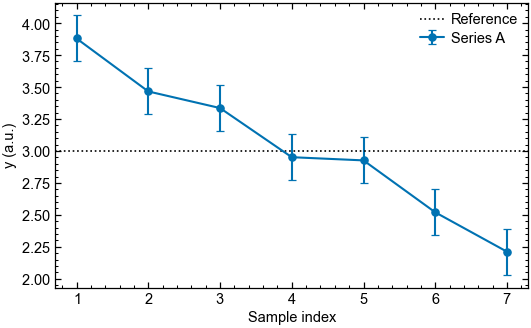

In [6]:
preview("elsevier")
categories = np.arange(1, 8)
values = 4.0 - 0.25 * categories + rng.normal(0, 0.1, categories.size)

fig, ax = jf.subplots("elsevier", width="single")
ax.errorbar(categories, values, yerr=0.18, marker="o", capsize=plt.rcParams["errorbar.capsize"],
            label="Series A")
ax.axhline(3.0, linestyle=":", linewidth=0.8, color=jf.COLORS["black"], label="Reference")
ax.set_xlabel("Sample index")
ax.set_ylabel("y (a.u.)")
ax.legend()

## Greyscale safety for points

Colour alone will not survive a greyscale print. Vary the marker **shape**, and use an open marker
(`markerfacecolor="none"`) when points overlap heavily.

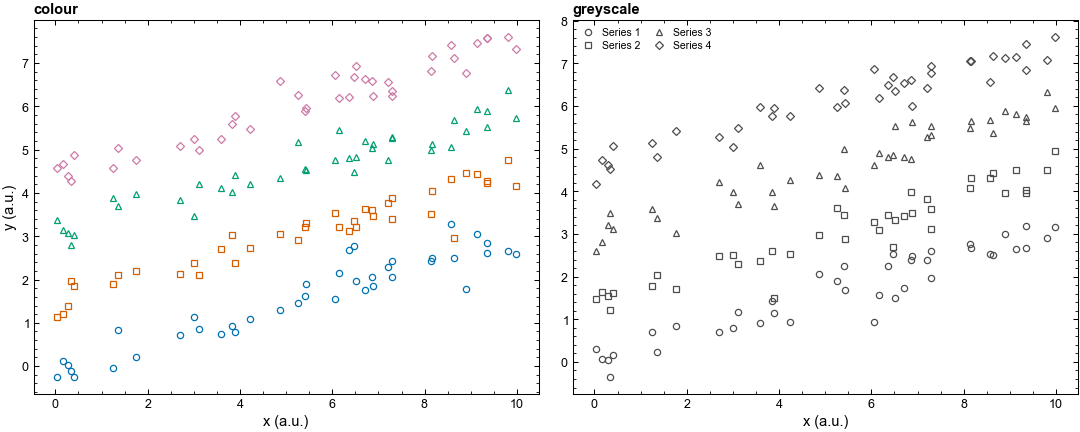

In [7]:
preview("nature")
fig, axs = jf.subplots("nature", 1, 2, width="double", ratio=0.4)

for ax, grey in zip(axs, [False, True]):
    for i, marker in enumerate(jf.MARKER_CYCLE[:4]):
        colour = "0.3" if grey else jf.COLOR_CYCLE[i]
        ax.plot(x, 0.3 * x + i * 1.5 + rng.normal(0, 0.3, x.size), linestyle="none",
                marker=marker, markerfacecolor="none", color=colour, label=f"Series {i + 1}")
    ax.set_xlabel("x (a.u.)")
    ax.set_title("greyscale" if grey else "colour")
axs[0].set_ylabel("y (a.u.)")
axs[1].legend(fontsize=5, ncols=2)